# Laboratorio 1: Requests & NLP Básico

En este laboratorio daremos un paso fundamental: conectarnos a una página web real. Utilizaremos la librería `requests` para descargar el documento y luego Beautiful Soup para estructurarlo.

Además de la extracción directa, incorporaremos elementos de Procesamiento de Lenguaje Natural (NLP Básico). Emplearemos `nltk` para filtrar 'palabras vacías' (*stopwords* como artículos o conectores) y como cierre generaremos una Nube de Palabras visual. Recordá siempre verificar el estado de la conexión del servidor antes de iniciar el procesamiento.

In [1]:
# Instalamos las librerías necesarias para el laboratorio
!pip install requests beautifulsoup4 wordcloud matplotlib nltk -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importamos las librerías base para conexión (requests) y estructuración (bs4)
import requests
from bs4 import BeautifulSoup

In [3]:
url = "https://www.gutenberg.org/cache/epub/58221/pg58221-images.html"

# Hacemos el pedido GET al servidor web
pagina = requests.get(url)

# ¡Importante! Revisamos si el pedido fue exitoso (código 200). Evitá procesar si te tira error.
pagina.raise_for_status()

# Extraemos el texto crudo devuelto por la petición
contenido = pagina.text

Con el texto descargado, instanciamos el árbol de análisis estructurado (el objeto `soup`).

In [4]:
soup = BeautifulSoup(contenido, "html.parser")

### El método find_all()
Cuando buscamos información masiva (como la totalidad de los párrafos en un documento), utilizamos `find_all("p")`. Notemos que este método devuelve un objeto iterable (similar a una lista) que contiene cada coincidencia existente en todo el árbol HTML.

In [5]:
parrafos = soup.find_all("p")
print(f"Encontramos {len(parrafos)} párrafos.")

Encontramos 2033 párrafos.


In [6]:
h1 = soup.find_all("h1")
print("Encabezado de la página:", h1[0].text if h1 else "No encontrado")

Encabezado de la página: LA ODISEA


In [7]:
italicas = soup.find_all("i") 

### Obteniendo frecuencias de palabras
Si deseamos determinar la frecuencia de aparición de un término, necesitamos aislar **exclusivamente** el texto lingüístico final. Si utilizamos `str(soup)`, transformaremos el HTML completo (incluyendo etiquetas estructurales y atributos CSS). Dicho formato no nos sirve para análisis de texto puro; requerimos únicamente el contenido visible de la Odisea.

In [8]:
from collections import Counter

# Extraemos el texto visible de toda la página limpiando el HTML con get_text()
texto_limpio_pagina = soup.get_text().lower()

print("Apariciones de 'ulises':", texto_limpio_pagina.count("ulises"))

Apariciones de 'ulises': 1705


In [9]:
def buscar_palabra(palabra):
  ocurrencias = texto_limpio_pagina.count(palabra.lower())
  print(f"Encontraste la palabra '{palabra}' {ocurrencias} veces")

buscar_palabra("Ciclope")
buscar_palabra("Minerva")
buscar_palabra("Alcínoo")
buscar_palabra("CANTO")

Encontraste la palabra 'Ciclope' 82 veces
Encontraste la palabra 'Minerva' 373 veces
Encontraste la palabra 'Alcínoo' 130 veces
Encontraste la palabra 'CANTO' 114 veces


### Desafío Práctico
Podemos construir un pequeño generador de extractos aleatorios de la Odisea interactuando con las etiquetas `<p>` previamente almacenadas.

In [10]:
import random

# Mostramos un pasaje aleatorio
# 'parrafos' ya lo definimos más arriba como la búsqueda de todos los tags <p>
parrafo_aleatorio = random.choice(parrafos).text.strip()

print("\nLee un pasaje aleatorio de la Odisea")
print("-------------------------------------------")
print(parrafo_aleatorio)
print("-------------------------------------------")
print(f"Este párrafo tiene {len(parrafo_aleatorio.split())} palabras.")


Lee un pasaje aleatorio de la Odisea
-------------------------------------------
445 «¡Óyeme, oh soberano,
quienquiera que seas! Vengo á ti, tan deseado, huyendo del ponto y de
las amenazas de Neptuno. Es digno de respeto aun para los inmortales
dioses el hombre que se presenta errabundo, como llego ahora á tu
corriente y á tus rodillas después de pasar muchos trabajos. ¡Oh rey,
apiádate de mí, ya que me glorío de ser tu suplicante!»
-------------------------------------------
Este párrafo tiene 64 palabras.


## Visualizaciones (WordCloud)
Depurar el texto base es una fase fundamental. Una nube de frecuencias estructurada perdería su valor analítico si estuviese dominada por conectores y artículos ortográficos. Por este motivo, aplicaremos herramientas de filtrado.

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re

# Descargamos las stopwords en español silenciosamente
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('spanish'))

### Expresiones Regulares (Regex)
Antes de procesar, notarás el uso de la librería `re`. Las **Expresiones Regulares** son secuencias de caracteres que forman un patrón de búsqueda estandarizado. En Ciencia de Datos, son el estándar de la industria para localizar, validar o reemplazar cadenas de texto de forma masiva.

En nuestra función de depuración, el patrón `r'[^\w\s]'` actúa como un colador estricto: instruye al motor a buscar **cualquier carácter que NO sea una letra, un número o un espacio**, procediendo a eliminarlo (reemplazarlo por nada `''`). Esto purga instantáneamente toda la puntuación (, . ; ! ?) del corpus.

In [12]:
# Función para limpiar y tokenizar el texto final
def depurar_texto(texto):
    texto_minusculas = texto.lower()
    # Limitamos los carácteres (borramos puntuación usando regex)
    texto_sin_puntuacion = re.sub(r'[^\w\s]', '', texto_minusculas)
    lista_palabras = texto_sin_puntuacion.split()

    palabras_importantes = []
    for palabra in lista_palabras:
        if palabra not in stop_words:
            palabras_importantes.append(palabra)

    return palabras_importantes

# Obtener otra vez el texto completo
texto_completo = soup.get_text()
palabras_limpias = depurar_texto(texto_completo)

# Reensamblamos todo en un string global con espacios
texto_limpio = ' '.join(palabras_limpias)

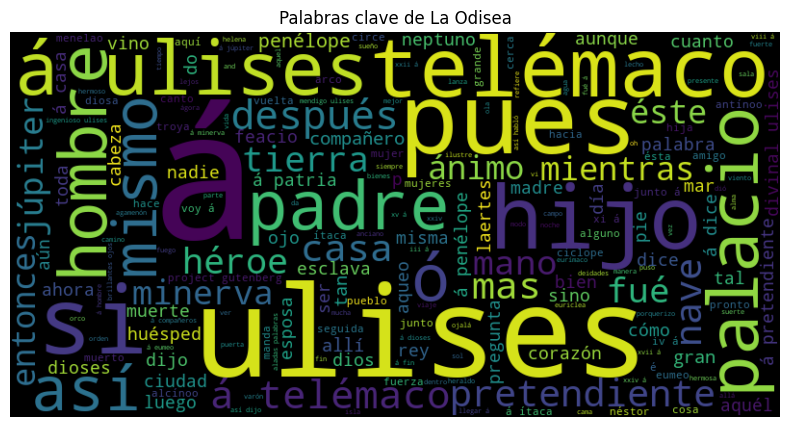

In [13]:
# Nube de palabras de La Odisea
wordcloud = WordCloud(width=800, height=400,
                      background_color='black',
                      stopwords=stop_words,
                      contour_width=3,
                      contour_color='steelblue').generate(texto_limpio)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras clave de La Odisea')
plt.show()

### Iteración Analítica: Stopwords Personalizadas
Como habrás observado en la visualización anterior, la librería genérica de *stopwords* en español captura los artículos más obvios ("el", "la"), pero palabras estructurales de la época ("si", "así", "pues", "bien") siguen dominando el gráfico, distrayéndonos de los sustantivos y verbos clave.

Procederemos a inyectar una lista manual de palabras vacías adicionales (propias del corpus literario) a nuestra colección y re-depuraremos.

In [14]:
# Añadimos palabras que no aportan valor semántico al conjunto (set) de stopwords
palabras_extra = ["si", "así", "pues", "bien", "cómo", "aún", "tal", "ser", "dijo", "respondió", "á"]
stop_words.update(palabras_extra)

# Volvemos a depurar el texto base original con las nuevas reglas
palabras_limpias_iteracion = depurar_texto(texto_completo)
texto_limpio_iteracion = ' '.join(palabras_limpias_iteracion)

print(f"El texto original tenía {len(texto_completo.split())} palabras.")
print(f"En esta iteración nos quedamos con {len(palabras_limpias_iteracion)} palabras clave.")

El texto original tenía 176384 palabras.
En esta iteración nos quedamos con 94125 palabras clave.


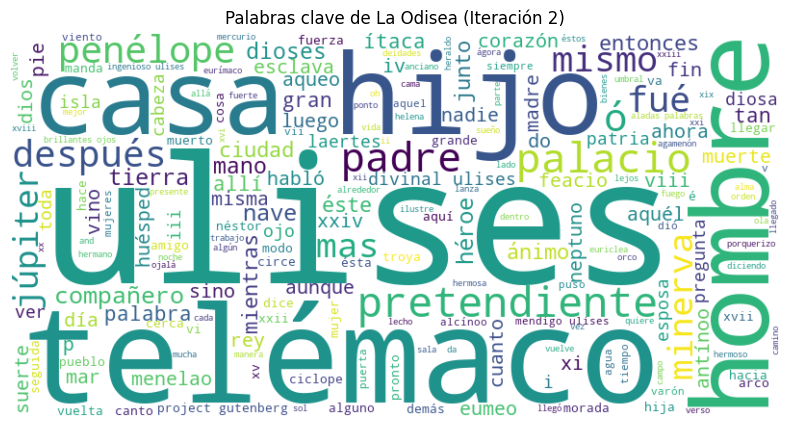

In [15]:
# Generamos la nueva nube de frecuencias refinada
wordcloud_2 = WordCloud(width=800, height=400,
                      background_color='white',
                      stopwords=stop_words,
                      contour_width=3,
                      contour_color='darkblue').generate(texto_limpio_iteracion)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_2, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras clave de La Odisea (Iteración 2)')
plt.show()

---
# Consolidación y Repaso

## Glosario Acotado
*   **Petición HTTP (Request):** Acción técnica mediante la cual una máquina operando como cliente solicita a un servidor remoto el envío de un recurso de red (como el código estático de una página web).
*   **Método `.find_all()`:** Función de búsqueda profunda en Beautiful Soup que, en lugar de detenerse tras el primer hallazgo, escanea la totalidad del DOM y retorna un listado de todos los nodos coincidentes.
*   **Stopwords (Palabras Vacías):** Términos de altísima frecuencia en un lenguaje genérico (ej. preposiciones, artículos) que carecen de peso semántico específico, y son habitualmente depurados durante el procesamiento de Lenguaje Natural (NLP).
*   **Expresiones Regulares (Regex):** Secuencia de caracteres algorítmica utilizada para representar patrones de búsqueda precisos en cadenas de texto. Herramienta primordial para la limpieza (Data Cleansing) y validación de entidades.

## Preguntas de Autoevaluación

**1. ¿Con qué fin se utiliza `pagina.raise_for_status()` tras efectuar la petición HTTP?**
Se utiliza como mecanismo de validación para confirmar que el recurso objetivo existe y que la respuesta del servidor web fue exitosa (código de estado 200). Ignorar la cabecera real de respuesta generará errores lógicos críticos en las metodologías posteriores, al asumir erróneamente que se recibió un cuerpo HTML válido.

**2. ¿Cuál es la principal diferencia técnica entre extraer texto con `.get_text()` en lugar de forzar un casting de string con `str(soup)`?**
Aplicar un casting de tipo nativo (`str()`) mantiene incrustado todo el código de hipertexto, incluyendo etiquetas de maquetado y los atributos internos. Extraer mediante `.get_text()` ignora completamente el esqueleto HTML, aislando la versión puramente textual de manera limpia.